# Accuracy × Difficulty Level Analysis
### Digit Span Backwards — STIM ON vs OFF × Easy / Medium / Hard / God Level

| Difficulty | Digits |
|---|---|
| 🟢 Easy | 2 digits |
| 🟡 Medium | 3 digits |
| 🔴 Hard | 4 digits |
| ⚡ God Level | 5 digits |

**Behavioral stats only** — no neural metrics.

## Cell 1 — Imports

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy import stats
from pathlib import Path
from itertools import product
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams.update({
    'font.family':       'sans-serif',
    'font.size':         11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth':    1.2,
    'figure.dpi':        150,
    'savefig.dpi':       180,
    'savefig.bbox':      'tight',
    'savefig.facecolor': 'white',
})

# ── Colour scheme ────────────────────────────────────────────────────────────
C_ON  = '#1A56DB'   # STIM ON  → blue
C_OFF = '#90A4AE'   # STIM OFF → grey
C_S2  = '#E65100'   # Session 2 → orange
C_S3  = '#2E7D32'   # Session 3 → green

# Difficulty palette
DIFF_META = {
    2: dict(label='Easy',      emoji='🟢', color='#43A047'),
    3: dict(label='Medium',    emoji='🟡', color='#F9A825'),
    4: dict(label='Hard',      emoji='🔴', color='#E53935'),
    5: dict(label='God Level', emoji='⚡', color='#6A1B9A'),
}

print('Imports OK')

Imports OK


## Cell 2 — File Paths  ← EDIT THESE

In [2]:
JSON_PATH_S2   = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Neural Data\DBS ATN DSB Case 1\D. Siragusa\3.5.26\Time stamp 1433\Report_Json_Session_Report_20260305T151703.json")
CSV_PATH_S2    = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Eprime Data\Digit Span Backwards v3.2\DigitSpanBackward v3.3-6-2-Scores.csv")
EVENTS_PATH_S2 = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\Events.csv")
OUT_DIR_S2     = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2")

JSON_PATH_S3   = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Neural Data\DBS ATN DSB Case 1\D. Siragusa\3.5.26\Time stamp 1441\Report_Json_Session_Report_20260305T151912.json")
CSV_PATH_S3    = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Eprime Data\Digit Span Backwards v3.2\DigitSpanBackward v3.3-6-3-Scores.csv")
EVENTS_PATH_S3 = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3\Preprocessed Data\Events.csv")
OUT_DIR_S3     = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3")

COMBINED_DIR   = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Combined")
COMBINED_DIR.mkdir(parents=True, exist_ok=True)

STIM_THRESHOLD = 2.0
print('Paths set.')

Paths set.


## Cell 3 — Data Loading + Alignment Pipeline

In [3]:
def load_session(json_path, csv_path, events_path, stim_threshold=2.0):
    with open(json_path) as f:
        report = json.load(f)
    df = pd.read_csv(csv_path,    encoding='utf-8-sig', low_memory=False)
    ev = pd.read_csv(events_path, encoding='utf-8-sig', low_memory=False)

    subject = str(df['Subject'].iloc[0])
    session = str(df['Session'].iloc[0])
    date    = str(df['SessionDate'].iloc[0])

    # Alignment anchor
    stim_start_tick = None
    for stream in report['BrainSenseLfp']:
        prev = None
        for pkt in stream['LfpData']:
            curr = pkt['Left']['mA']
            if prev is not None and prev == 0.0 and curr > 0.0:
                stim_start_tick = pkt['TicksInMs']
                break
            prev = curr
        if stim_start_tick: break
    assert stim_start_tick, 'No 0→>0 mA transition found!'

    welcome_ms    = int(df['Welcome.TargetOnsetTime'].iloc[0])
    MANUAL_OFFSET = stim_start_tick - welcome_ms

    def to_rel(ms):  return float(ms) + MANUAL_OFFSET - stim_start_tick
    def tick_to_rel(arr): return np.asarray(arr, dtype=float) - stim_start_tick

    # mA trace
    bslf_tick, bslf_mA = [], []
    for stream in report['BrainSenseLfp']:
        for pkt in stream['LfpData']:
            bslf_tick.append(pkt['TicksInMs'])
            bslf_mA.append(pkt['Left']['mA'])
    bslf_rel = tick_to_rel(np.array(bslf_tick, dtype=float))
    bslf_mA  = np.array(bslf_mA, dtype=float)

    # Digit sequences
    digit_rows = df['Digit'].tolist()
    trial_digit_seqs, offset = {}, 0
    for tn in range(1, 15):
        row = ev[(ev['Event_Type']=='Main Trial Start') & (ev['Trial_Number']==tn)]
        if row.empty: continue
        n = int(row.iloc[0]['Num_Digits'])
        trial_digit_seqs[tn] = digit_rows[offset:offset+n]
        offset += n

    def ev_times_all(etype, tn):
        rows = ev[(ev['Event_Type']==etype) & (ev['Trial_Number']==tn)]
        return [float(x) for x in rows['Time_ms'].tolist()]
    def ev_first(etype, tn):
        v = ev_times_all(etype, tn); return v[0] if v else None

    trials = []
    for tn in range(1, 15):
        sr = ev[(ev['Event_Type']=='Main Trial Start') & (ev['Trial_Number']==tn)]
        if sr.empty: continue
        r = sr.iloc[0]
        t = dict(
            num=tn,
            digits=int(r['Num_Digits']) if pd.notna(r['Num_Digits']) else None,
            acc=int(r['ACC'])           if pd.notna(r['ACC'])        else None,
            cresp=str(int(r['CRESP']))  if pd.notna(r['CRESP'])      else '?',
            resp=str(int(r['RESP']))    if pd.notna(r['RESP'])        else '?',
            digit_seq=trial_digit_seqs.get(tn, []),
        )
        for key, etype in [('start','Main Trial Start'),('end','Main Trial End'),
                            ('cs','Choice Start'),('ce','Choice End'),
                            ('fb_s','Feedback Start'),('fb_e','Feedback End')]:
            ms = ev_first(etype, tn)
            t[key] = to_rel(ms) if ms is not None else None
        trials.append(t)

    meta = dict(subject=subject, session=session, date=date)
    print(f'Loaded: Subject={subject}  Session={session}  Date={date}  Trials={len(trials)}')
    return trials, bslf_rel, bslf_mA, meta


def classify_trials(trials, bslf_rel, bslf_mA, threshold=2.0):
    """Tag each trial: stim_on = True if ≥50% of trial window has mA ≥ threshold."""
    for t in trials:
        t0, t1 = t['start'], t['end']
        if t0 is None or t1 is None or t1 <= t0:
            t.update(stim_on=False, stim_frac=0.0); continue
        mask = (bslf_rel >= t0) & (bslf_rel <= t1)
        t_r, t_m = bslf_rel[mask], bslf_mA[mask]
        if len(t_r) < 2:
            t.update(stim_on=False, stim_frac=0.0); continue
        dt        = np.diff(t_r)
        mid_mA    = (t_m[:-1] + t_m[1:]) / 2.0
        total     = t_r[-1] - t_r[0]
        stim_frac = np.sum(dt[mid_mA >= threshold]) / total if total > 0 else 0.0
        t.update(stim_on=stim_frac >= 0.5, stim_frac=float(stim_frac))
    return trials


print('Pipeline functions defined.')

Pipeline functions defined.


## Cell 4 — Statistics Functions (behavioral only)

In [4]:
def fisher_test(n_correct_a, n_a, n_correct_b, n_b):
    """Fisher's Exact: group A vs group B. Returns (p, risk_diff)."""
    if n_a == 0 or n_b == 0:
        return np.nan, np.nan
    table = [[n_correct_a, n_a - n_correct_a],
             [n_correct_b, n_b - n_correct_b]]
    _, p  = stats.fisher_exact(table)
    rd    = (n_correct_a/n_a) - (n_correct_b/n_b)
    return float(p), float(rd)


def build_df(sessions):
    """
    sessions: list of (label, trials)
    Returns tidy DataFrame with one row per trial.
    """
    rows = []
    for label, trials in sessions:
        for t in trials:
            d = t.get('digits', None)
            if d is None: continue
            dm = DIFF_META.get(d, dict(label=f'{d}-digit', emoji='', color='#555'))
            rows.append(dict(
                session      = label,
                trial_num    = t['num'],
                digits       = d,
                diff_label   = dm['label'],
                diff_color   = dm['color'],
                diff_emoji   = dm['emoji'],
                acc          = t['acc'],
                stim_on      = t.get('stim_on', False),
                stim_frac    = t.get('stim_frac', 0.0),
                resp         = t.get('resp', '?'),
                cresp        = t.get('cresp', '?'),
            ))
    return pd.DataFrame(rows)


def compute_cell_stats(df, group_col, group_vals=None):
    """
    For each value of group_col, compute STIM ON vs OFF stats.
    Returns DataFrame with one row per (group_val, stim_condition).
    """
    if group_vals is None:
        group_vals = sorted(df[group_col].unique())
    rows = []
    for gv in group_vals:
        sub = df[df[group_col] == gv]
        for stim in [True, False]:
            g   = sub[sub['stim_on'] == stim]
            nc  = int(g['acc'].sum())
            nt  = len(g)
            acc = nc/nt if nt > 0 else np.nan
            rows.append(dict(
                group=gv, stim_on=stim,
                n_correct=nc, n_total=nt, accuracy=acc
            ))
    return pd.DataFrame(rows)


def stats_table(df, group_col, group_vals=None):
    """
    Fisher's Exact for each level of group_col (STIM ON vs OFF).
    Returns DataFrame: group | n_on | acc_on | n_off | acc_off | p | risk_diff | sig
    """
    if group_vals is None:
        group_vals = sorted(df[group_col].unique())
    rows = []
    for gv in group_vals:
        sub  = df[df[group_col] == gv]
        on   = sub[sub['stim_on'] == True]
        off  = sub[sub['stim_on'] == False]
        p, rd = fisher_test(int(on['acc'].sum()), len(on),
                             int(off['acc'].sum()), len(off))
        rows.append(dict(
            group     = gv,
            n_on      = len(on),
            correct_on= int(on['acc'].sum()),
            acc_on    = on['acc'].mean() if len(on) else np.nan,
            n_off     = len(off),
            correct_off=int(off['acc'].sum()),
            acc_off   = off['acc'].mean() if len(off) else np.nan,
            p_fisher  = p,
            risk_diff = rd,
            sig       = ('*' if p < 0.05 else 'ns') if not np.isnan(p) else 'N/A',
        ))
    return pd.DataFrame(rows)


def _sig_stars(p):
    if np.isnan(p):   return ''
    if p < 0.001:     return '***'
    if p < 0.01:      return '**'
    if p < 0.05:      return '*'
    return 'ns'


print('Stats functions defined.')

Stats functions defined.


## Cell 5 — Plotting Functions

In [5]:
# ─── shared bracket helper ────────────────────────────────────────────────────
def _bracket(ax, x0, x1, y_frac, p, rd, fontsize=8.5, transform=None):
    """Draw a significance bracket between bar positions x0 and x1."""
    if np.isnan(p): return
    color = '#D32F2F' if p < 0.05 else '#9E9E9E'
    tr    = transform or ax.transData
    ydata = ax.get_ylim()[1] * y_frac
    pad   = ax.get_ylim()[1] * 0.03
    ax.plot([x0, x0, x1, x1],
            [ydata, ydata+pad, ydata+pad, ydata],
            lw=1.3, color=color, zorder=6)
    rd_s = f'  RD={rd:.2f}' if not np.isnan(rd) else ''
    ax.text((x0+x1)/2, ydata+pad*1.2,
            f'{_sig_stars(p)}  p={p:.3f}{rd_s}',
            ha='center', va='bottom', fontsize=fontsize,
            color=color, fontweight='bold', zorder=7)


# ─────────────────────────────────────────────────────────────────────────────
# PLOT A: Overall STIM ON vs OFF accuracy (no difficulty split)
# ─────────────────────────────────────────────────────────────────────────────
def plot_overall_accuracy(df, label, save_path=None):
    on  = df[df['stim_on'] == True]
    off = df[df['stim_on'] == False]

    accs   = [on['acc'].mean()*100  if len(on)  else 0,
              off['acc'].mean()*100 if len(off) else 0]
    counts = [(int(on['acc'].sum()), len(on)),
              (int(off['acc'].sum()), len(off))]

    p, rd = fisher_test(counts[0][0], counts[0][1],
                        counts[1][0], counts[1][1])

    fig, ax = plt.subplots(figsize=(5.5, 5))
    bars = ax.bar(['STIM ON', 'STIM OFF'], accs, color=[C_ON, C_OFF],
                  width=0.42, zorder=3, edgecolor='white', lw=1.5)

    for i, (nc, nt) in enumerate(counts):
        if nt > 0:
            se = np.sqrt(accs[i]/100*(1-accs[i]/100)/nt)*100
            ax.errorbar(i, accs[i], yerr=se, fmt='none',
                        color='#333', capsize=6, lw=2, zorder=4)
        ax.text(i, accs[i]+4, f'{nc}/{nt}\n({accs[i]:.0f}%)',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_ylim(0, 140)
    _bracket(ax, 0, 1, 1.05, p, rd)
    ax.set_yticks([0,25,50,75,100])
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_title(f'Overall Accuracy: STIM ON vs OFF\n{label}',
                 fontsize=12, fontweight='bold')
    ax.axhline(50, color='#ddd', lw=1, ls='--')
    ax.yaxis.grid(True, color='#eee', zorder=0); ax.set_axisbelow(True)
    handles = [mpatches.Patch(color=C_ON,  label=f'STIM ON  (n={len(on)})'),
               mpatches.Patch(color=C_OFF, label=f'STIM OFF (n={len(off)})')]
    ax.legend(handles=handles, fontsize=9, loc='upper right',
              framealpha=0.9, edgecolor='#ccc')
    fig.tight_layout()
    if save_path: fig.savefig(save_path); print(f'Saved → {save_path}')
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# PLOT B: Accuracy per difficulty — grouped bar (ON vs OFF side-by-side)
# ─────────────────────────────────────────────────────────────────────────────
def plot_accuracy_by_difficulty(df, label, save_path=None):
    diff_levels = sorted([d for d in df['digits'].unique() if d in DIFF_META])
    n  = len(diff_levels)
    bw = 0.30
    xs = np.arange(n)

    fig, ax = plt.subplots(figsize=(max(6, n*2.2), 5.5))

    st = stats_table(df, 'digits', diff_levels)

    for ci, (stim, color, off) in enumerate(
            [(True, C_ON, -bw/2), (False, C_OFF, bw/2)]):
        ys, errs, lbls = [], [], []
        for d in diff_levels:
            row = st[st['group']==d].iloc[0]
            nc  = row['correct_on']  if stim else row['correct_off']
            nt  = row['n_on']        if stim else row['n_off']
            acc = nc/nt*100 if nt>0 else 0
            err = np.sqrt(acc/100*(1-acc/100)/nt)*100 if nt>0 else 0
            ys.append(acc); errs.append(err); lbls.append((int(nc), int(nt)))
        bars = ax.bar(xs+off, ys, width=bw, color=color, zorder=3,
                      edgecolor='white', lw=1.3,
                      label='STIM ON' if stim else 'STIM OFF', alpha=0.88)
        ax.errorbar(xs+off, ys, yerr=errs, fmt='none',
                    color='#333', capsize=4, lw=1.8, zorder=4)
        for x, y, (nc, nt) in zip(xs+off, ys, lbls):
            ax.text(x, y+2, f'{nc}/{nt}',
                    ha='center', va='bottom', fontsize=8, fontweight='bold')

    # significance brackets above each difficulty group
    ax.set_ylim(0, 145)
    for i, d in enumerate(diff_levels):
        row = st[st['group']==d].iloc[0]
        _bracket(ax, i-bw/2, i+bw/2, 1.08,
                 row['p_fisher'], row['risk_diff'], fontsize=8)

    # x-axis labels with emoji + difficulty name
    xlabels = [f"{DIFF_META[d]['emoji']} {DIFF_META[d]['label']}\n({d} digits)"
               for d in diff_levels]
    ax.set_xticks(xs)
    ax.set_xticklabels(xlabels, fontsize=10.5)
    ax.set_yticks([0,25,50,75,100])
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_title(f'Accuracy by Difficulty Level: STIM ON vs OFF\n{label}',
                 fontsize=12, fontweight='bold')
    ax.axhline(50, color='#ddd', lw=1, ls='--')
    ax.yaxis.grid(True, color='#eee', zorder=0); ax.set_axisbelow(True)
    ax.legend(fontsize=10, framealpha=0.9, edgecolor='#ccc', loc='upper right')
    fig.tight_layout()
    if save_path: fig.savefig(save_path); print(f'Saved → {save_path}')
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# PLOT C: Accuracy heatmap — Session × Difficulty × Stim condition
# ─────────────────────────────────────────────────────────────────────────────
def plot_heatmap(df, label, save_path=None):
    diff_levels = sorted([d for d in df['digits'].unique() if d in DIFF_META])
    sessions    = sorted(df['session'].unique())
    stim_labels = {True: 'STIM ON', False: 'STIM OFF'}

    # rows = sessions × stim_condition  |  cols = difficulty
    row_keys = [(s, st) for s in sessions for st in [True, False]]
    mat      = np.full((len(row_keys), len(diff_levels)), np.nan)
    annot    = np.empty_like(mat, dtype=object)

    for ri, (sess, stim) in enumerate(row_keys):
        for ci, d in enumerate(diff_levels):
            sub = df[(df['session']==sess) & (df['stim_on']==stim) & (df['digits']==d)]
            if len(sub) == 0:
                annot[ri, ci] = '—'
                continue
            nc = int(sub['acc'].sum())
            nt = len(sub)
            mat[ri, ci]   = nc/nt*100
            annot[ri, ci] = f'{nc/nt*100:.0f}%\n({nc}/{nt})'

    fig, ax = plt.subplots(figsize=(max(6, len(diff_levels)*2), len(row_keys)*1.2 + 1.5))
    im = ax.imshow(mat, vmin=0, vmax=100, cmap='RdYlGn', aspect='auto')

    for ri in range(len(row_keys)):
        for ci in range(len(diff_levels)):
            val  = mat[ri, ci]
            txt  = annot[ri, ci]
            tc   = 'white' if (not np.isnan(val) and (val < 30 or val > 75)) else '#222'
            ax.text(ci, ri, txt, ha='center', va='center',
                    fontsize=9.5, fontweight='bold', color=tc)

    cbar = fig.colorbar(im, ax=ax, shrink=0.6, pad=0.02)
    cbar.set_label('Accuracy (%)', fontsize=10)

    xlabels = [f"{DIFF_META[d]['emoji']}\n{DIFF_META[d]['label']}\n({d} dig)"
               for d in diff_levels]
    ylabels = [f'{sess}\n{stim_labels[stim]}' for sess, stim in row_keys]

    ax.set_xticks(range(len(diff_levels)))
    ax.set_xticklabels(xlabels, fontsize=10)
    ax.set_yticks(range(len(row_keys)))
    ax.set_yticklabels(ylabels, fontsize=9.5)

    # horizontal dividers between sessions
    for i in range(1, len(sessions)):
        ax.axhline(i*2 - 0.5, color='white', lw=2)

    ax.set_title(f'Accuracy Heatmap: Session × Difficulty × Stim State\n{label}',
                 fontsize=12, fontweight='bold', pad=10)
    fig.tight_layout()
    if save_path: fig.savefig(save_path); print(f'Saved → {save_path}')
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# PLOT D: Trial strip — colored by difficulty + stim state
# ─────────────────────────────────────────────────────────────────────────────
def plot_difficulty_strip(df, label, save_path=None):
    diff_levels = sorted([d for d in df['digits'].unique() if d in DIFF_META])
    n_diff = len(diff_levels)

    fig, axes = plt.subplots(n_diff, 1,
                             figsize=(11, n_diff * 2.2),
                             sharex=False)
    if n_diff == 1: axes = [axes]

    rng = np.random.default_rng(42)

    for ax, d in zip(axes, diff_levels):
        dm  = DIFF_META[d]
        sub = df[df['digits'] == d].copy()

        for _, row in sub.iterrows():
            fc  = C_ON  if row['stim_on'] else C_OFF
            mk  = 'o'   if row['acc'] == 1 else 'X'
            jit = rng.uniform(-0.09, 0.09)
            # use session as edge color
            ec  = C_S2 if row['session'].endswith('2') else C_S3
            ax.scatter(row['trial_num'], row['acc']+jit,
                       c=fc, marker=mk, s=110,
                       edgecolors=ec, linewidths=1.8,
                       zorder=4, alpha=0.90)

        ax.set_ylim(-0.4, 1.65)
        ax.set_yticks([0,1])
        ax.set_yticklabels(['✗','✓'], fontsize=12)
        ax.set_ylabel(f"{dm['emoji']} {dm['label']}",
                      fontsize=10, fontweight='bold',
                      color=dm['color'])
        ax.grid(True, axis='x', color='#eee', lw=0.8)

        # mini stats annotation
        on  = sub[sub['stim_on']==True]
        off = sub[sub['stim_on']==False]
        acc_on  = on['acc'].mean()*100  if len(on)  else np.nan
        acc_off = off['acc'].mean()*100 if len(off) else np.nan
        p, rd   = fisher_test(int(on['acc'].sum()), len(on),
                               int(off['acc'].sum()), len(off))
        ann = (f'ON: {acc_on:.0f}%  OFF: {acc_off:.0f}%  '
               f'p={p:.3f} {_sig_stars(p)}') if not np.isnan(p) else ''
        ax.text(0.98, 0.88, ann, transform=ax.transAxes,
                ha='right', va='top', fontsize=8.5,
                color='#D32F2F' if (not np.isnan(p) and p<0.05) else '#555',
                fontweight='bold')

    axes[-1].set_xlabel('Trial Number', fontsize=11)
    fig.suptitle(f'Trial Strip by Difficulty Level\n{label}\n'
                 f'(fill = Stim state | edge = Session)',
                 fontsize=12, fontweight='bold', y=1.01)

    handles = [
        mpatches.Patch(color=C_ON,  label='STIM ON (fill)'),
        mpatches.Patch(color=C_OFF, label='STIM OFF (fill)'),
        Line2D([0],[0], marker='o', color='w', markeredgecolor=C_S2,
               markersize=9, markeredgewidth=2, label='Session 2 (edge)'),
        Line2D([0],[0], marker='o', color='w', markeredgecolor=C_S3,
               markersize=9, markeredgewidth=2, label='Session 3 (edge)'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='#555',
               markersize=8, label='Correct (○)'),
        Line2D([0],[0], marker='X', color='w', markerfacecolor='#555',
               markersize=8, label='Incorrect (✕)'),
    ]
    fig.legend(handles=handles, fontsize=8.5, loc='lower center',
               ncol=3, framealpha=0.92, edgecolor='#ccc',
               bbox_to_anchor=(0.5, -0.04))
    fig.tight_layout()
    if save_path: fig.savefig(save_path, bbox_inches='tight'); print(f'Saved → {save_path}')
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# PLOT E: Line plot — accuracy vs difficulty, ON vs OFF
# ─────────────────────────────────────────────────────────────────────────────
def plot_difficulty_line(df, label, save_path=None):
    diff_levels = sorted([d for d in df['digits'].unique() if d in DIFF_META])
    xs = np.arange(len(diff_levels))

    fig, ax = plt.subplots(figsize=(7, 5))

    for stim, color, lbl, mk in [
            (True,  C_ON,  'STIM ON',  'o'),
            (False, C_OFF, 'STIM OFF', 's')]:
        ys, errs = [], []
        for d in diff_levels:
            sub = df[(df['digits']==d) & (df['stim_on']==stim)]
            if len(sub) == 0:
                ys.append(np.nan); errs.append(0); continue
            nc  = int(sub['acc'].sum())
            nt  = len(sub)
            acc = nc/nt*100
            se  = np.sqrt(acc/100*(1-acc/100)/nt)*100 if nt > 1 else 0
            ys.append(acc); errs.append(se)

        ax.plot(xs, ys, color=color, lw=2.2, marker=mk,
                markersize=9, zorder=4, label=lbl)
        ax.fill_between(xs,
                         [y-e for y,e in zip(ys,errs)],
                         [y+e for y,e in zip(ys,errs)],
                         color=color, alpha=0.12, zorder=2)

    xlabels = [f"{DIFF_META[d]['emoji']} {DIFF_META[d]['label']}\n({d} digits)"
               for d in diff_levels]
    ax.set_xticks(xs)
    ax.set_xticklabels(xlabels, fontsize=10.5)
    ax.set_ylim(-5, 115)
    ax.set_yticks([0,25,50,75,100])
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_title(f'Accuracy vs Difficulty (STIM ON vs OFF)\n{label}',
                 fontsize=12, fontweight='bold')
    ax.axhline(50, color='#ddd', lw=1, ls='--')
    ax.yaxis.grid(True, color='#eee', zorder=0); ax.set_axisbelow(True)
    ax.legend(fontsize=10, framealpha=0.9, edgecolor='#ccc', loc='upper right')
    fig.tight_layout()
    if save_path: fig.savefig(save_path); print(f'Saved → {save_path}')
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# PLOT F: Session comparison — per difficulty, ON vs OFF
# ─────────────────────────────────────────────────────────────────────────────
def plot_session_x_difficulty(df, save_path=None):
    diff_levels = sorted([d for d in df['digits'].unique() if d in DIFF_META])
    sessions    = sorted(df['session'].unique())
    sess_colors = {s: c for s, c in zip(sessions, [C_S2, C_S3, '#7B1FA2'])}

    n_diff = len(diff_levels)
    fig, axes = plt.subplots(1, n_diff,
                              figsize=(n_diff * 3.8, 5.5),
                              sharey=True)
    if n_diff == 1: axes = [axes]

    bw  = 0.20
    n_s = len(sessions)
    total_width = bw * n_s * 2

    for ax, d in zip(axes, diff_levels):
        dm  = DIFF_META[d]
        sub = df[df['digits'] == d]

        group_idx = 0
        xtick_pos, xtick_lbl = [], []

        for si, sess in enumerate(sessions):
            sc = sess_colors[sess]
            for stim, color, slbl in [(True, C_ON, 'ON'), (False, C_OFF, 'OFF')]:
                g  = sub[(sub['session']==sess) & (sub['stim_on']==stim)]
                nc = int(g['acc'].sum()) if len(g) else 0
                nt = len(g)
                acc= nc/nt*100 if nt>0 else 0
                err= np.sqrt(acc/100*(1-acc/100)/nt)*100 if nt>1 else 0

                x = group_idx * bw
                ax.bar(x, acc, width=bw*0.85, color=color,
                       edgecolor=sc, linewidth=2.2,
                       zorder=3, alpha=0.88)
                ax.errorbar(x, acc, yerr=err, fmt='none',
                            color='#333', capsize=3, lw=1.5, zorder=4)
                ax.text(x, acc+2.5, f'{nc}/{nt}',
                        ha='center', va='bottom', fontsize=7.5, fontweight='bold')

                xtick_pos.append(x)
                xtick_lbl.append(f'{sess.split()[-1]}\n{slbl}')
                group_idx += 1
            group_idx += 1  # gap between sessions

        ax.set_xticks(xtick_pos)
        ax.set_xticklabels(xtick_lbl, fontsize=8)
        ax.set_title(f"{dm['emoji']} {dm['label']}\n({d} digits)",
                     fontsize=10.5, fontweight='bold', color=dm['color'])
        ax.set_ylim(0, 140)
        ax.axhline(50, color='#ddd', lw=1, ls='--')
        ax.yaxis.grid(True, color='#eee', zorder=0)
        ax.set_axisbelow(True)

    axes[0].set_ylabel('Accuracy (%)', fontsize=12)
    handles = [
        mpatches.Patch(color=C_ON,  label='STIM ON (fill)'),
        mpatches.Patch(color=C_OFF, label='STIM OFF (fill)'),
    ] + [Line2D([0],[0], marker='s', color='w',
                markeredgecolor=sess_colors[s], markersize=9,
                markeredgewidth=2.5, label=f'{s} (edge)')
         for s in sessions]

    fig.legend(handles=handles, fontsize=9, loc='lower center',
               ncol=4, framealpha=0.92, edgecolor='#ccc',
               bbox_to_anchor=(0.5, -0.05))
    fig.suptitle('Session × Difficulty × Stim State Accuracy',
                 fontsize=13, fontweight='bold', y=1.02)
    fig.tight_layout()
    if save_path: fig.savefig(save_path, bbox_inches='tight'); print(f'Saved → {save_path}')
    plt.show()


print('Plotting functions defined.')

Plotting functions defined.


## Cell 6 — Load + Classify Sessions

In [6]:
trials_s2, bslf_rel_s2, bslf_mA_s2, meta_s2 = load_session(
    JSON_PATH_S2, CSV_PATH_S2, EVENTS_PATH_S2, STIM_THRESHOLD)

trials_s3, bslf_rel_s3, bslf_mA_s3, meta_s3 = load_session(
    JSON_PATH_S3, CSV_PATH_S3, EVENTS_PATH_S3, STIM_THRESHOLD)

classify_trials(trials_s2, bslf_rel_s2, bslf_mA_s2, STIM_THRESHOLD)
classify_trials(trials_s3, bslf_rel_s3, bslf_mA_s3, STIM_THRESHOLD)

print('Classification done.')

Loaded: Subject=6  Session=2  Date=03-05-2026  Trials=14
Loaded: Subject=6  Session=3  Date=03-05-2026  Trials=14
Classification done.


## Cell 7 — Build DataFrames

In [7]:
df_s2  = build_df([('Session 2', trials_s2)])
df_s3  = build_df([('Session 3', trials_s3)])
df_all = build_df([('Session 2', trials_s2), ('Session 3', trials_s3)])

print('Session 2:')
display(df_s2[['trial_num','digits','diff_label','acc','stim_on','stim_frac']].to_string(index=False))
print('\nSession 3:')
display(df_s3[['trial_num','digits','diff_label','acc','stim_on','stim_frac']].to_string(index=False))

Session 2:


' trial_num  digits diff_label  acc  stim_on  stim_frac\n         1       2       Easy    1    False   0.000000\n         2       2       Easy    1    False   0.000000\n         3       3     Medium    1    False   0.263158\n         4       3     Medium    1    False   0.000000\n         5       4       Hard    1    False   0.000000\n         6       4       Hard    0    False   0.000000\n         7       4       Hard    0     True   0.960000\n         8       4       Hard    0     True   1.000000\n         9       4       Hard    1     True   1.000000\n        10       4       Hard    0     True   1.000000\n        11       4       Hard    0     True   1.000000\n        12       4       Hard    0     True   1.000000\n        13       4       Hard    0     True   1.000000\n        14       4       Hard    0     True   1.000000'


Session 3:


' trial_num  digits diff_label  acc  stim_on  stim_frac\n         1       2       Easy    1    False   0.000000\n         2       2       Easy    1    False   0.000000\n         3       3     Medium    1    False   0.450000\n         4       3     Medium    0    False   0.350000\n         5       3     Medium    0    False   0.000000\n         6       3     Medium    1    False   0.142857\n         7       3     Medium    0     True   0.526316\n         8       3     Medium    1    False   0.150000\n         9       3     Medium    0    False   0.095238\n        10       3     Medium    1     True   0.500000\n        11       3     Medium    0    False   0.000000\n        12       3     Medium    0    False   0.285714\n        13       3     Medium    1    False   0.000000\n        14       3     Medium    1    False   0.157895'

## Cell 8 — Stats Tables (print)

In [8]:
diff_order = sorted([d for d in df_all['digits'].unique() if d in DIFF_META])

for label, df in [('Session 2', df_s2), ('Session 3', df_s3), ('Combined', df_all)]:
    st = stats_table(df, 'digits', diff_order)
    print(f'\n{"="*70}')
    print(f'  {label} — Accuracy by Difficulty (Fisher\'s Exact, STIM ON vs OFF)')
    print(f'{"="*70}')
    for _, row in st.iterrows():
        dm = DIFF_META.get(int(row['group']), {})
        emoji = dm.get('emoji',''); lbl = dm.get('label', str(row['group']))
        print(f"  {emoji} {lbl:10s} ({int(row['group'])} dig) | "
              f"ON:  {row['correct_on']}/{int(row['n_on'])} ({row['acc_on']*100:.0f}%)  | "
              f"OFF: {row['correct_off']}/{int(row['n_off'])} ({row['acc_off']*100:.0f}%)  | "
              f"p={row['p_fisher']:.4f}  RD={row['risk_diff']:.2f}  {row['sig']}")


  Session 2 — Accuracy by Difficulty (Fisher's Exact, STIM ON vs OFF)
  🟢 Easy       (2 dig) | ON:  0/0 (nan%)  | OFF: 2/2 (100%)  | p=nan  RD=nan  N/A
  🟡 Medium     (3 dig) | ON:  0/0 (nan%)  | OFF: 2/2 (100%)  | p=nan  RD=nan  N/A
  🔴 Hard       (4 dig) | ON:  1/8 (12%)  | OFF: 1/2 (50%)  | p=0.3778  RD=-0.38  ns

  Session 3 — Accuracy by Difficulty (Fisher's Exact, STIM ON vs OFF)
  🟢 Easy       (2 dig) | ON:  0/0 (nan%)  | OFF: 2/2 (100%)  | p=nan  RD=nan  N/A
  🟡 Medium     (3 dig) | ON:  1/2 (50%)  | OFF: 5/10 (50%)  | p=1.0000  RD=0.00  ns
  🔴 Hard       (4 dig) | ON:  0/0 (nan%)  | OFF: 0/0 (nan%)  | p=nan  RD=nan  N/A

  Combined — Accuracy by Difficulty (Fisher's Exact, STIM ON vs OFF)
  🟢 Easy       (2 dig) | ON:  0/0 (nan%)  | OFF: 4/4 (100%)  | p=nan  RD=nan  N/A
  🟡 Medium     (3 dig) | ON:  1/2 (50%)  | OFF: 7/12 (58%)  | p=1.0000  RD=-0.08  ns
  🔴 Hard       (4 dig) | ON:  1/8 (12%)  | OFF: 1/2 (50%)  | p=0.3778  RD=-0.38  ns


## Cell 9 — Plot A: Overall Accuracy Bar

Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\diff_overall_Session_2.png


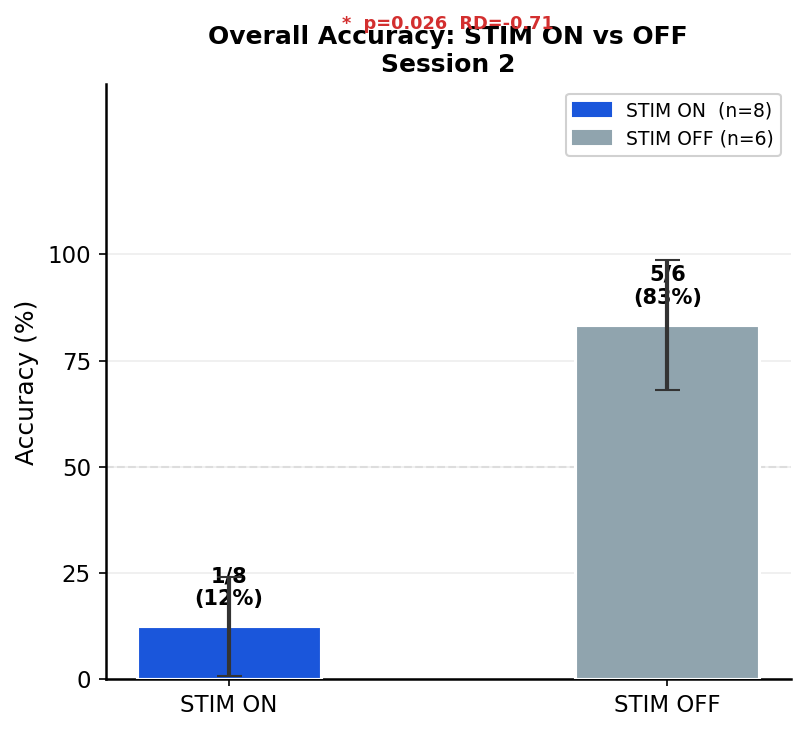

Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3\diff_overall_Session_3.png


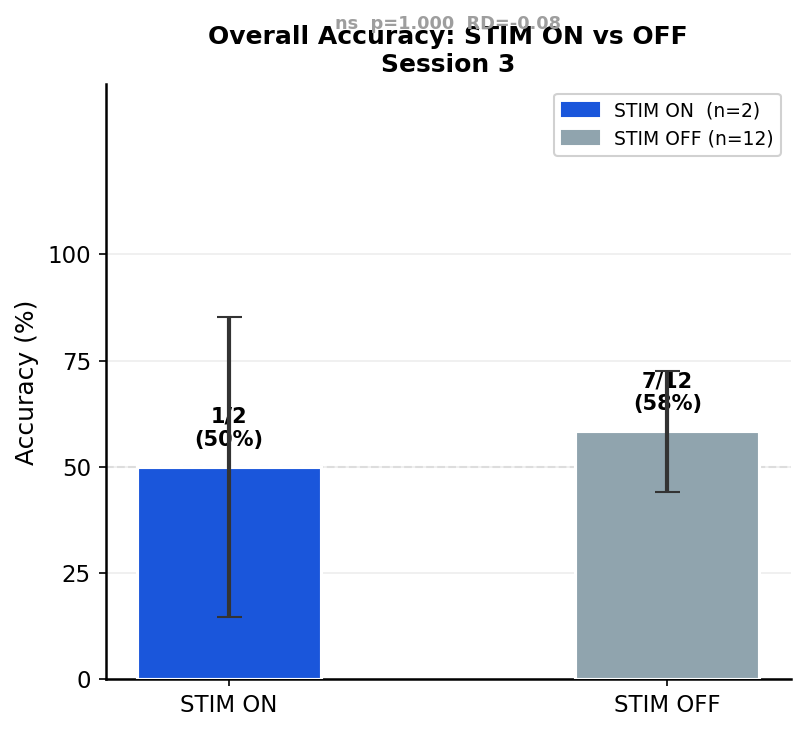

Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Combined\diff_overall_Combined_(S2+S3).png


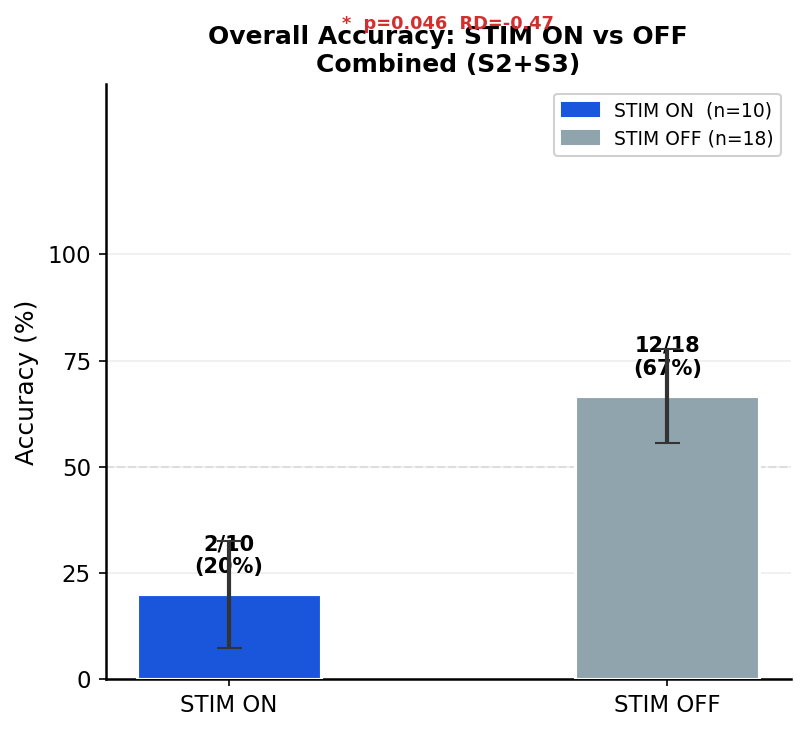

In [9]:
for label, df, odir in [
    ('Session 2',       df_s2,  OUT_DIR_S2),
    ('Session 3',       df_s3,  OUT_DIR_S3),
    ('Combined (S2+S3)', df_all, COMBINED_DIR),
]:
    plot_overall_accuracy(
        df, label,
        save_path=Path(odir) / f'diff_overall_{label.replace(" ","_")}.png'
    )

## Cell 10 — Plot B: Accuracy by Difficulty (grouped bar)

Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\diff_grouped_bar_Session_2.png


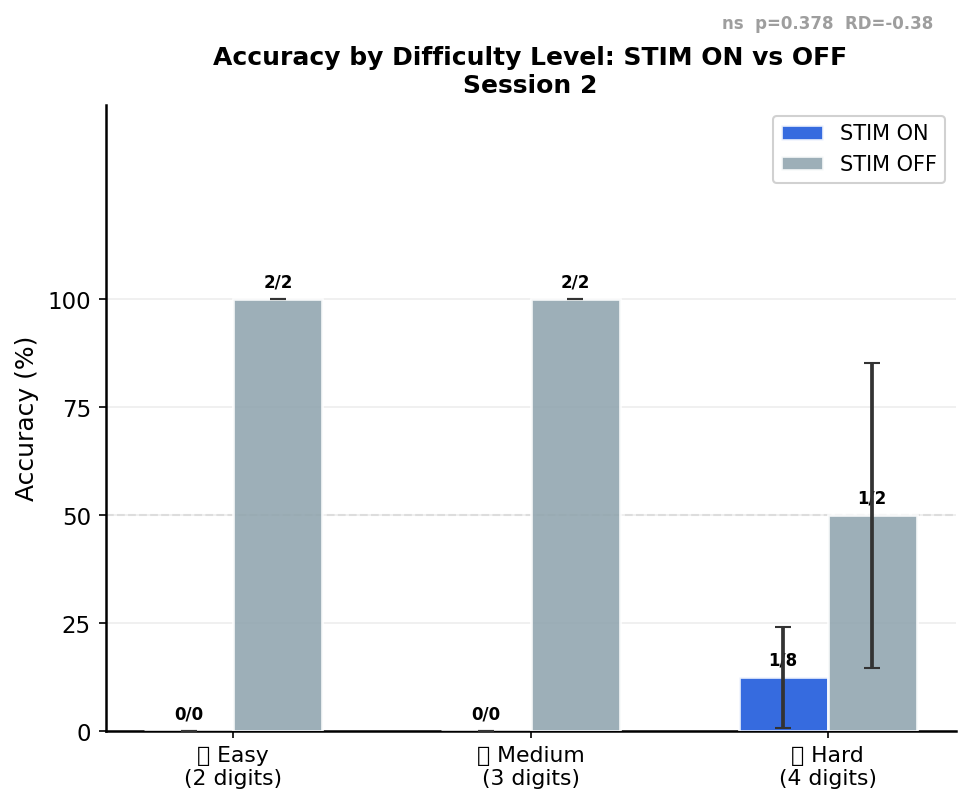

Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3\diff_grouped_bar_Session_3.png


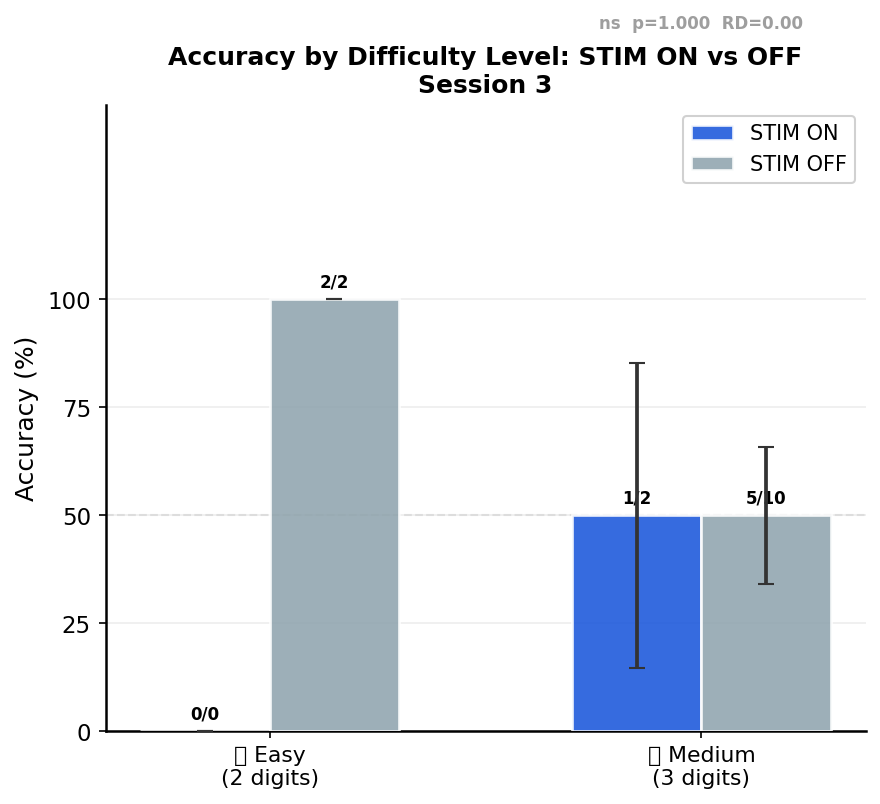

Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Combined\diff_grouped_bar_Combined_(S2+S3).png


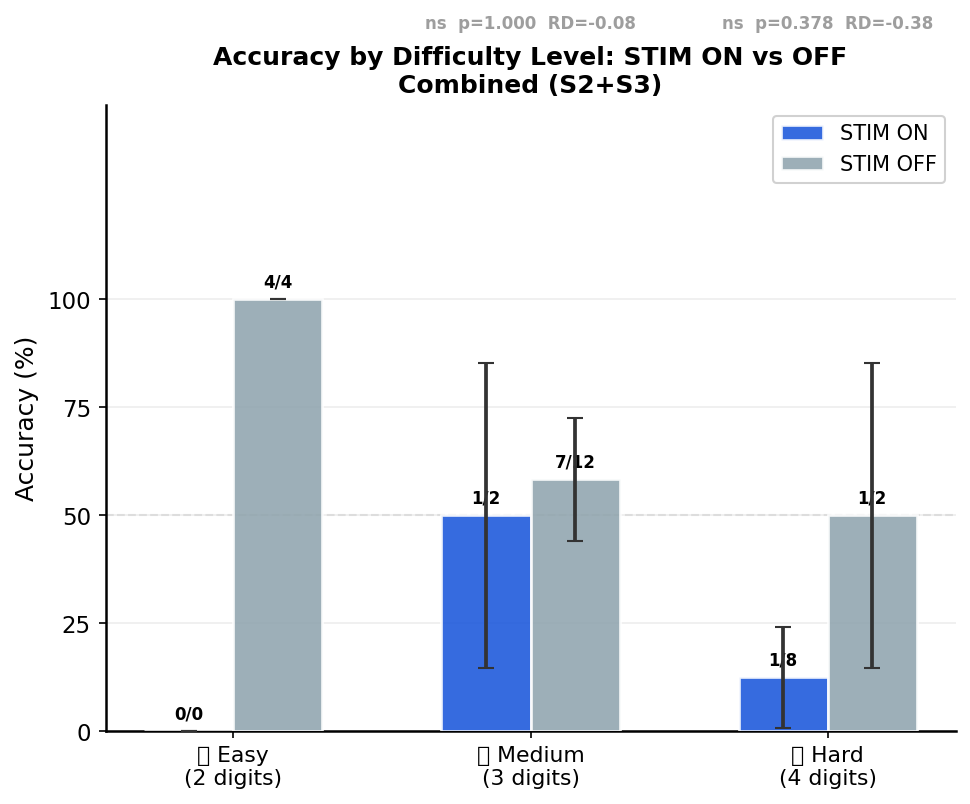

In [10]:
for label, df, odir in [
    ('Session 2',       df_s2,  OUT_DIR_S2),
    ('Session 3',       df_s3,  OUT_DIR_S3),
    ('Combined (S2+S3)', df_all, COMBINED_DIR),
]:
    plot_accuracy_by_difficulty(
        df, label,
        save_path=Path(odir) / f'diff_grouped_bar_{label.replace(" ","_")}.png'
    )

## Cell 11 — Plot C: Accuracy Heatmap

Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Combined\diff_heatmap_combined.png


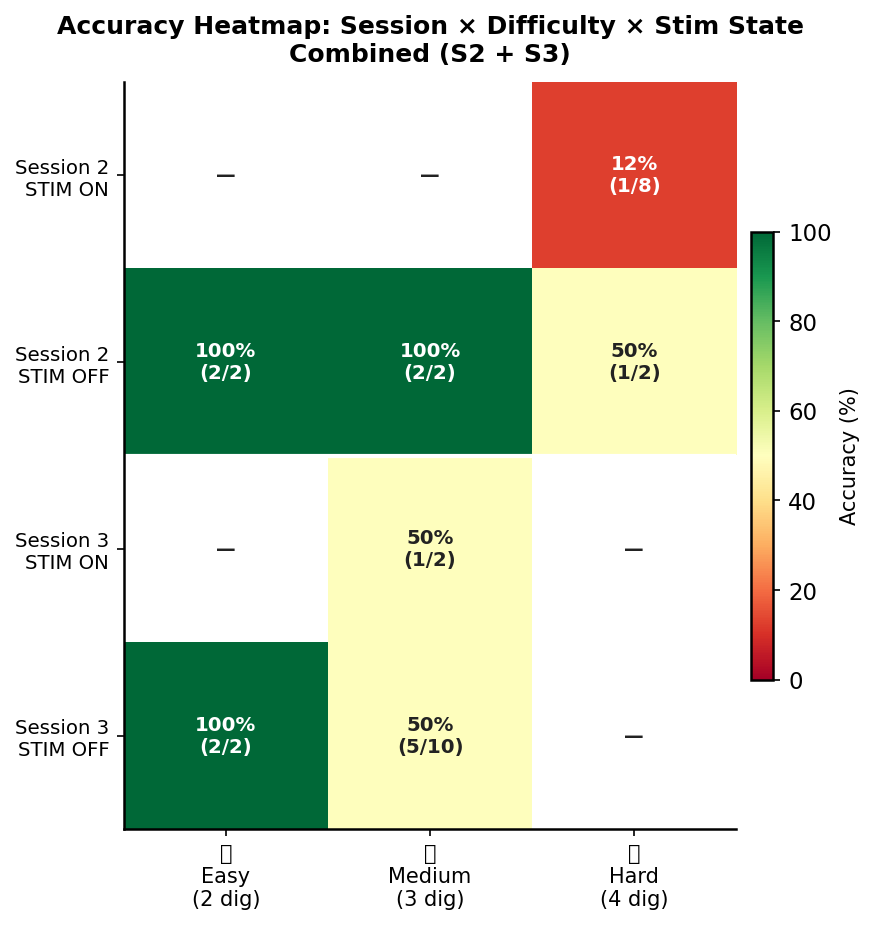

In [11]:
plot_heatmap(df_all, 'Combined (S2 + S3)',
             save_path=COMBINED_DIR / 'diff_heatmap_combined.png')

## Cell 12 — Plot D: Trial Strip by Difficulty

Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\diff_strip_Session_2.png


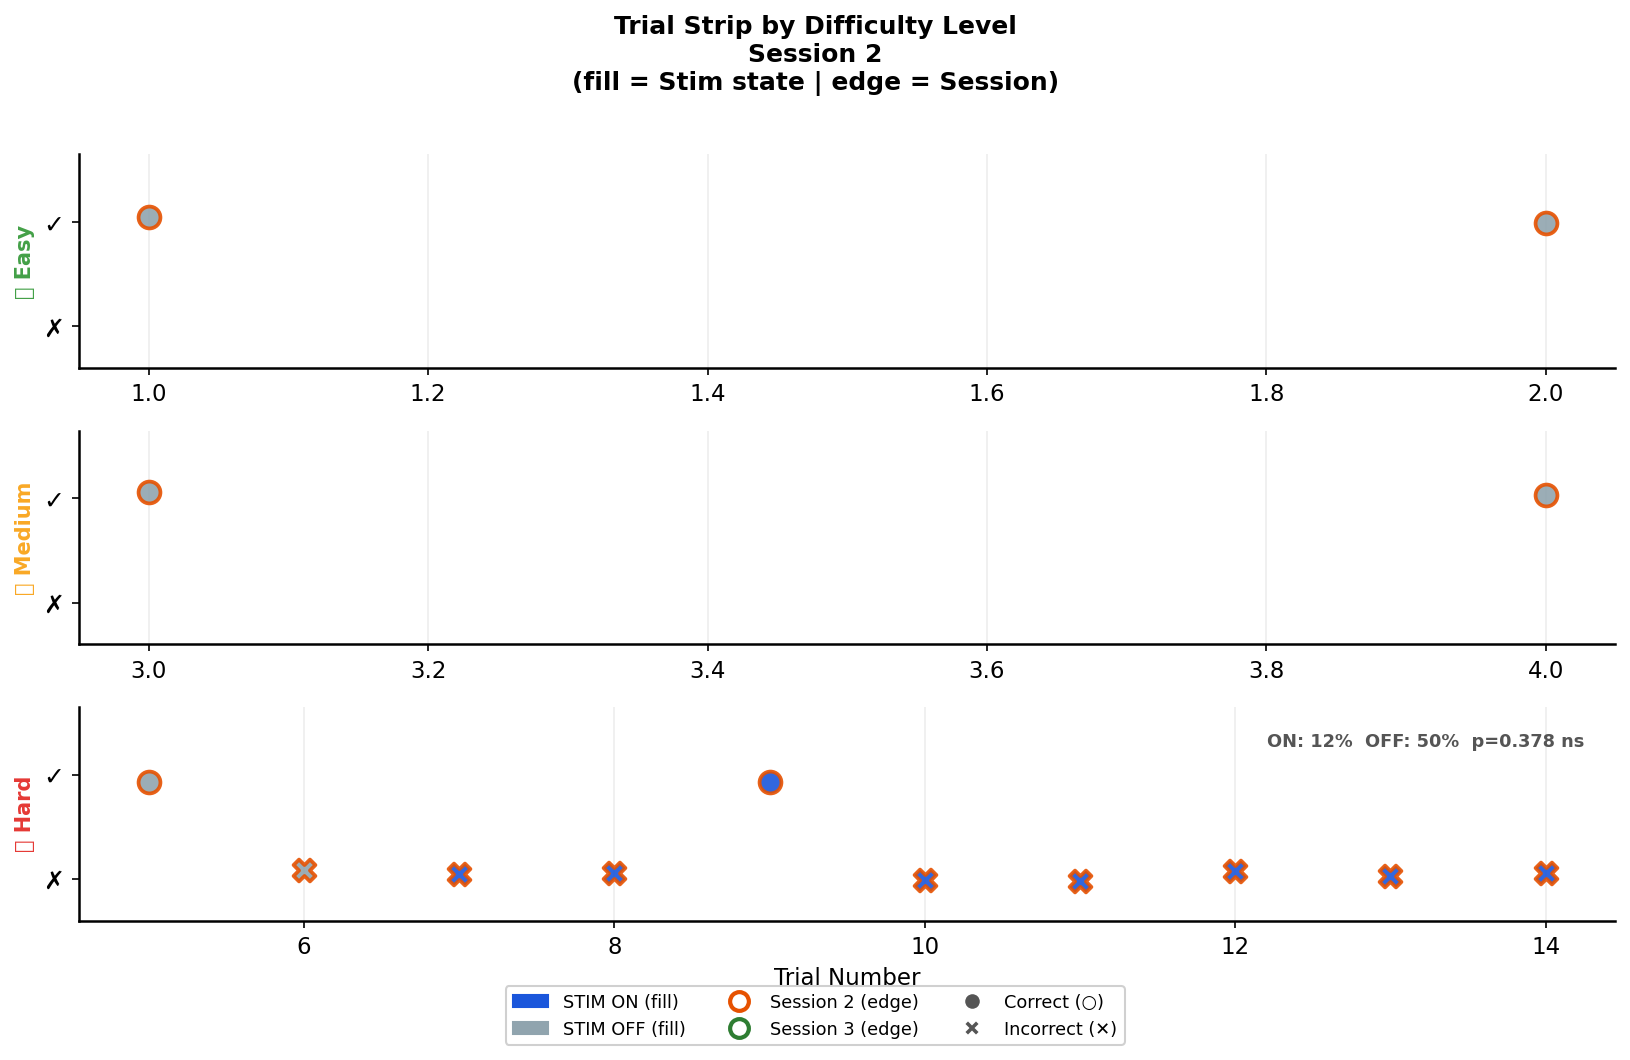

Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3\diff_strip_Session_3.png


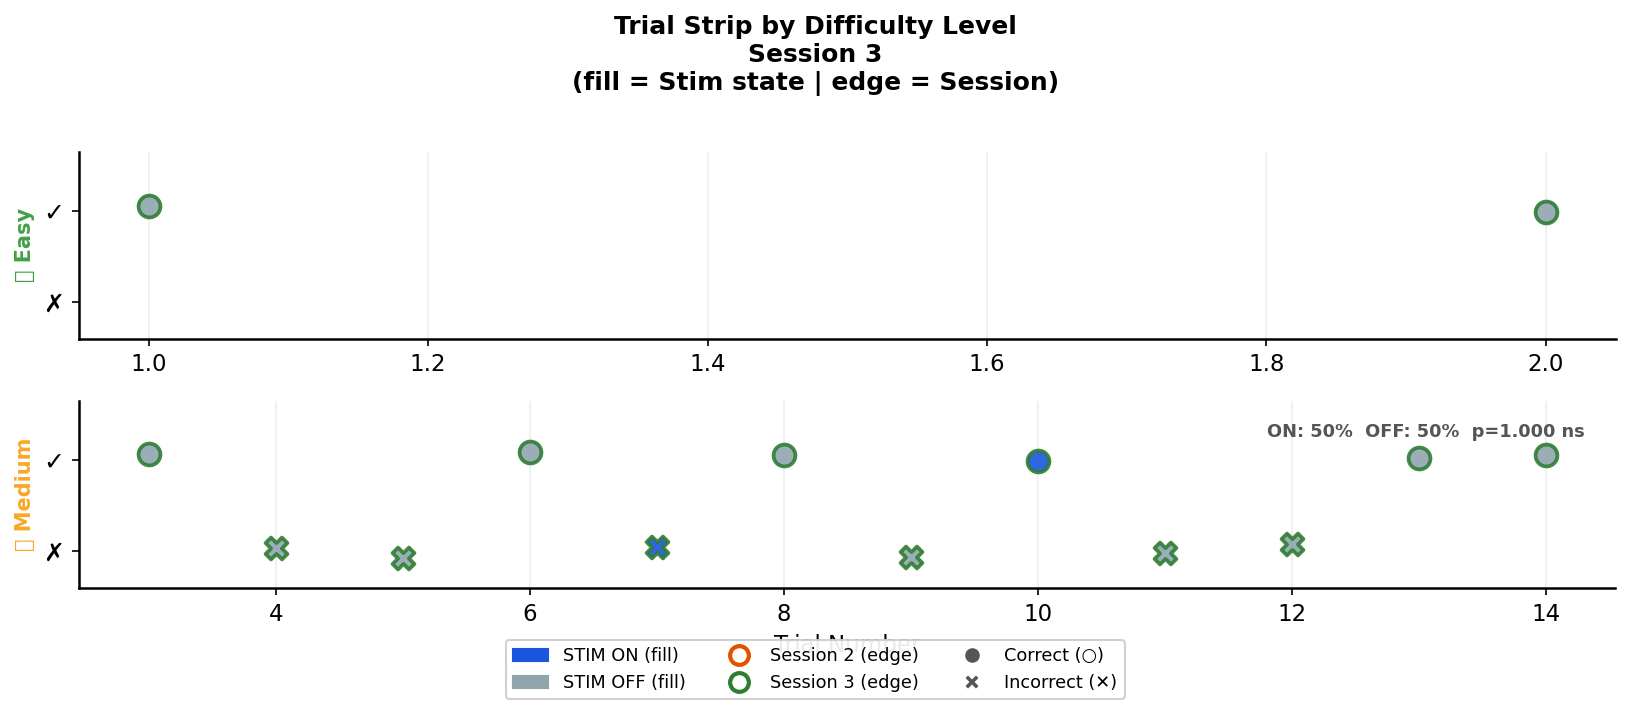

Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Combined\diff_strip_Combined_(S2+S3).png


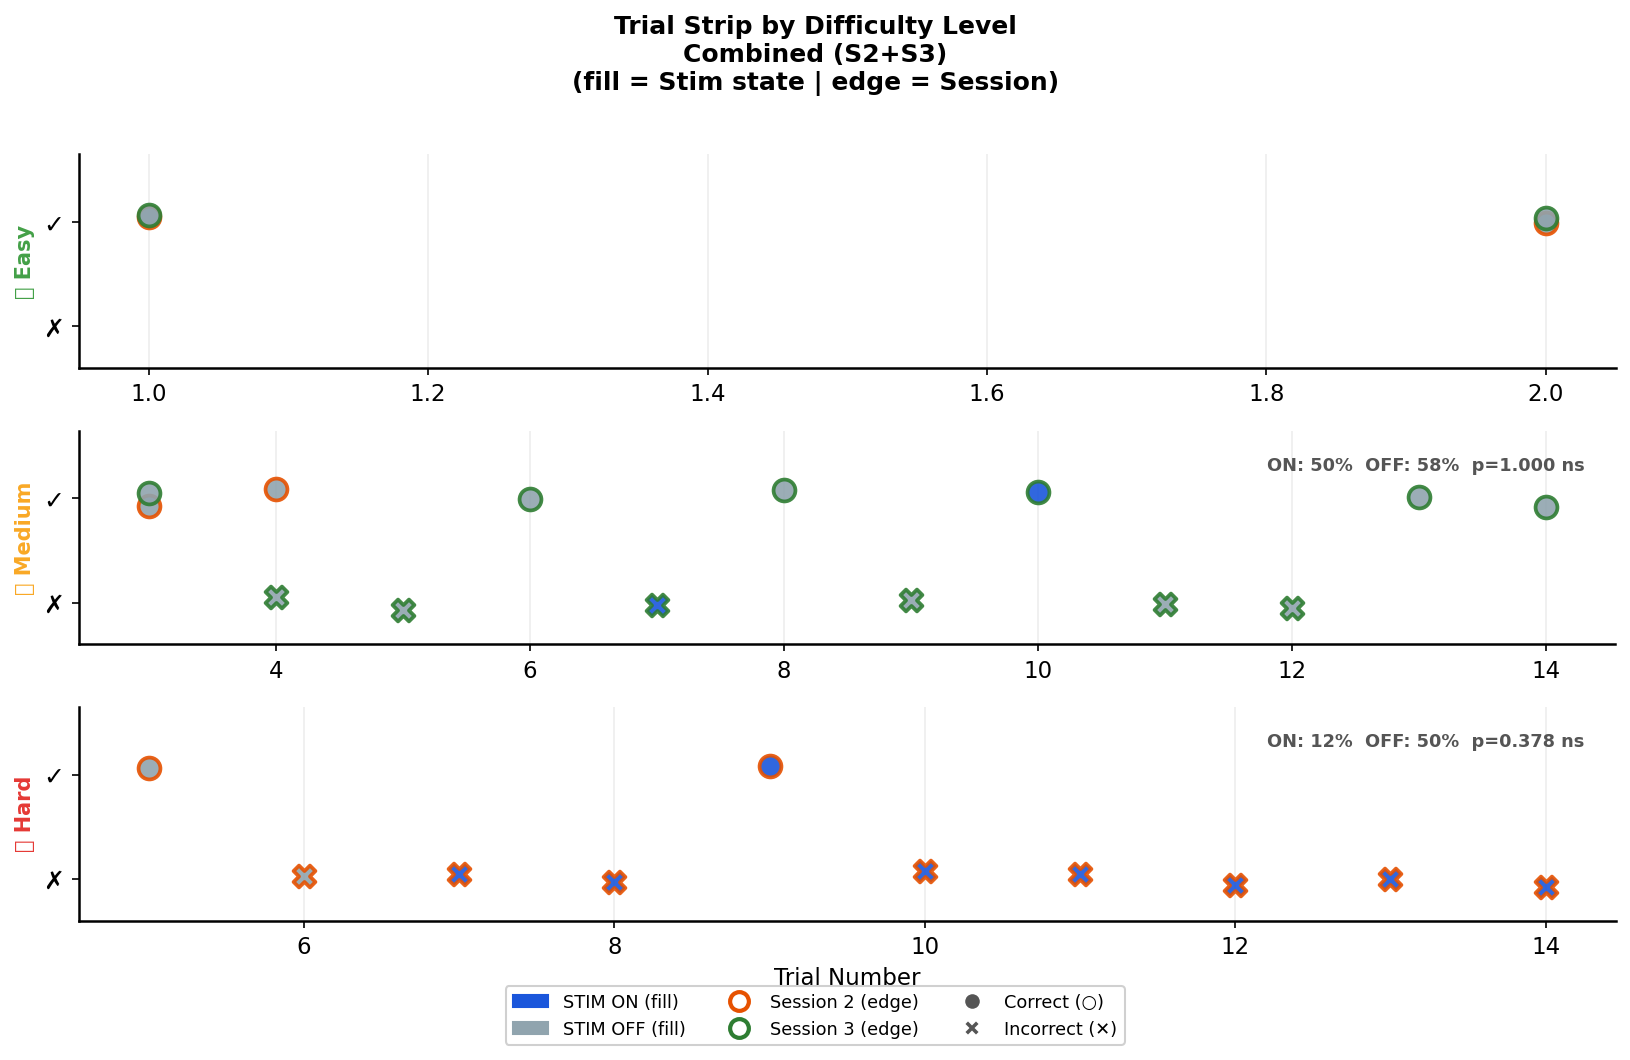

In [12]:
for label, df, odir in [
    ('Session 2',       df_s2,  OUT_DIR_S2),
    ('Session 3',       df_s3,  OUT_DIR_S3),
    ('Combined (S2+S3)', df_all, COMBINED_DIR),
]:
    plot_difficulty_strip(
        df, label,
        save_path=Path(odir) / f'diff_strip_{label.replace(" ","_")}.png'
    )

## Cell 13 — Plot E: Accuracy vs Difficulty Line Plot

Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\diff_line_Session_2.png


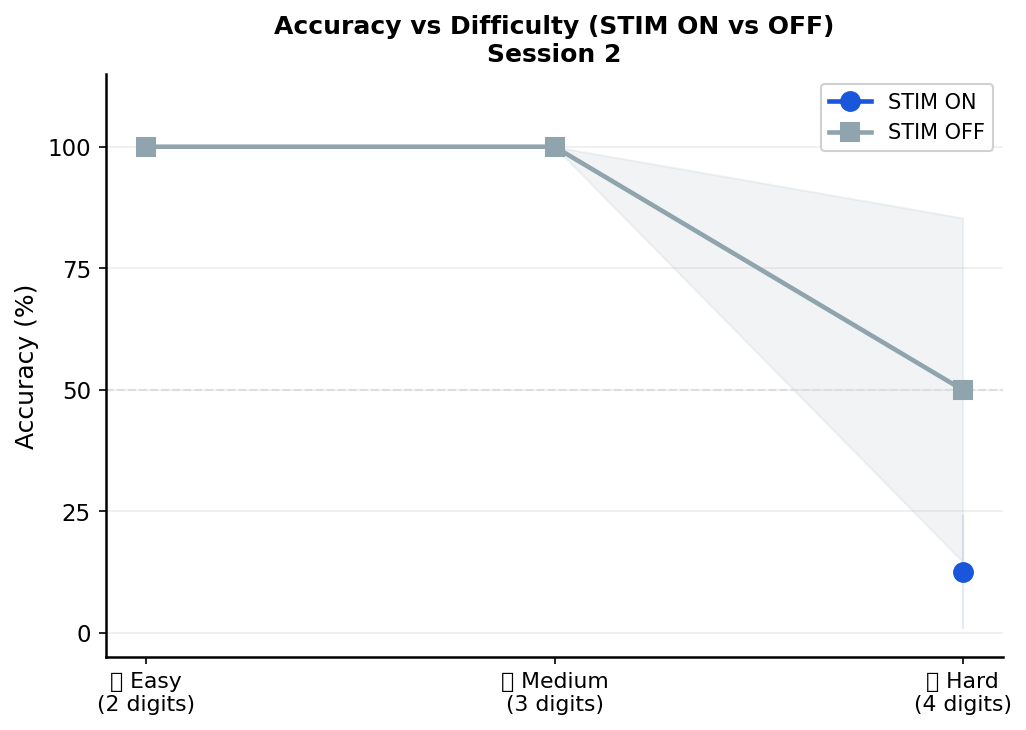

Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3\diff_line_Session_3.png


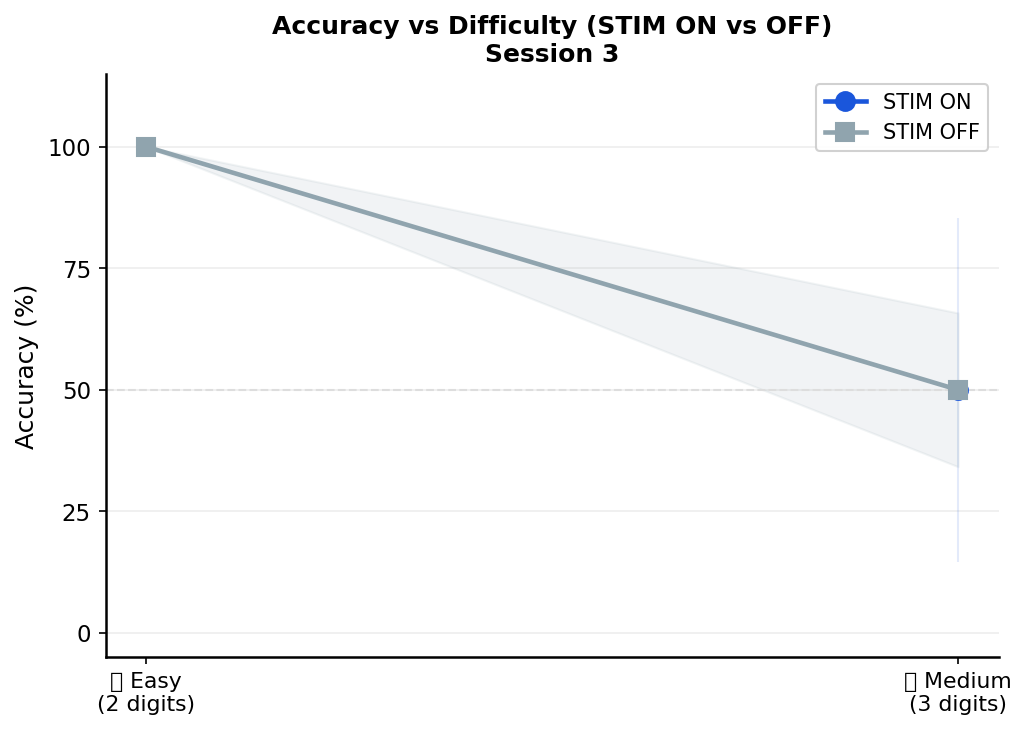

Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Combined\diff_line_Combined_(S2+S3).png


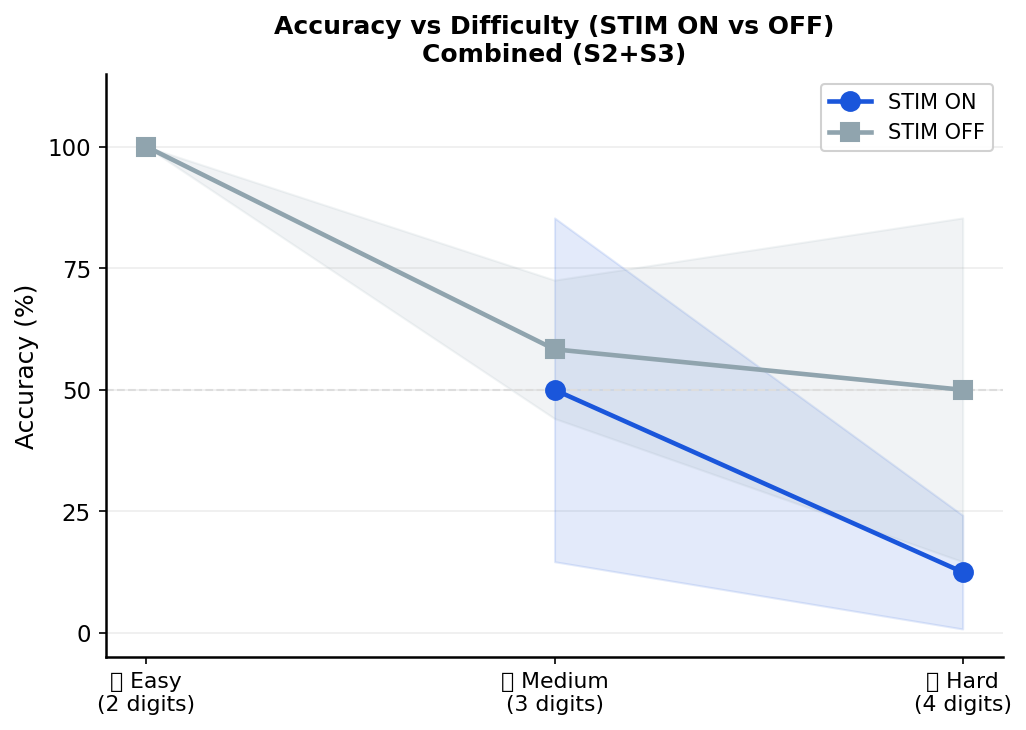

In [13]:
for label, df, odir in [
    ('Session 2',       df_s2,  OUT_DIR_S2),
    ('Session 3',       df_s3,  OUT_DIR_S3),
    ('Combined (S2+S3)', df_all, COMBINED_DIR),
]:
    plot_difficulty_line(
        df, label,
        save_path=Path(odir) / f'diff_line_{label.replace(" ","_")}.png'
    )

## Cell 14 — Plot F: Session × Difficulty × Stim Comparison

Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Combined\diff_session_x_difficulty.png


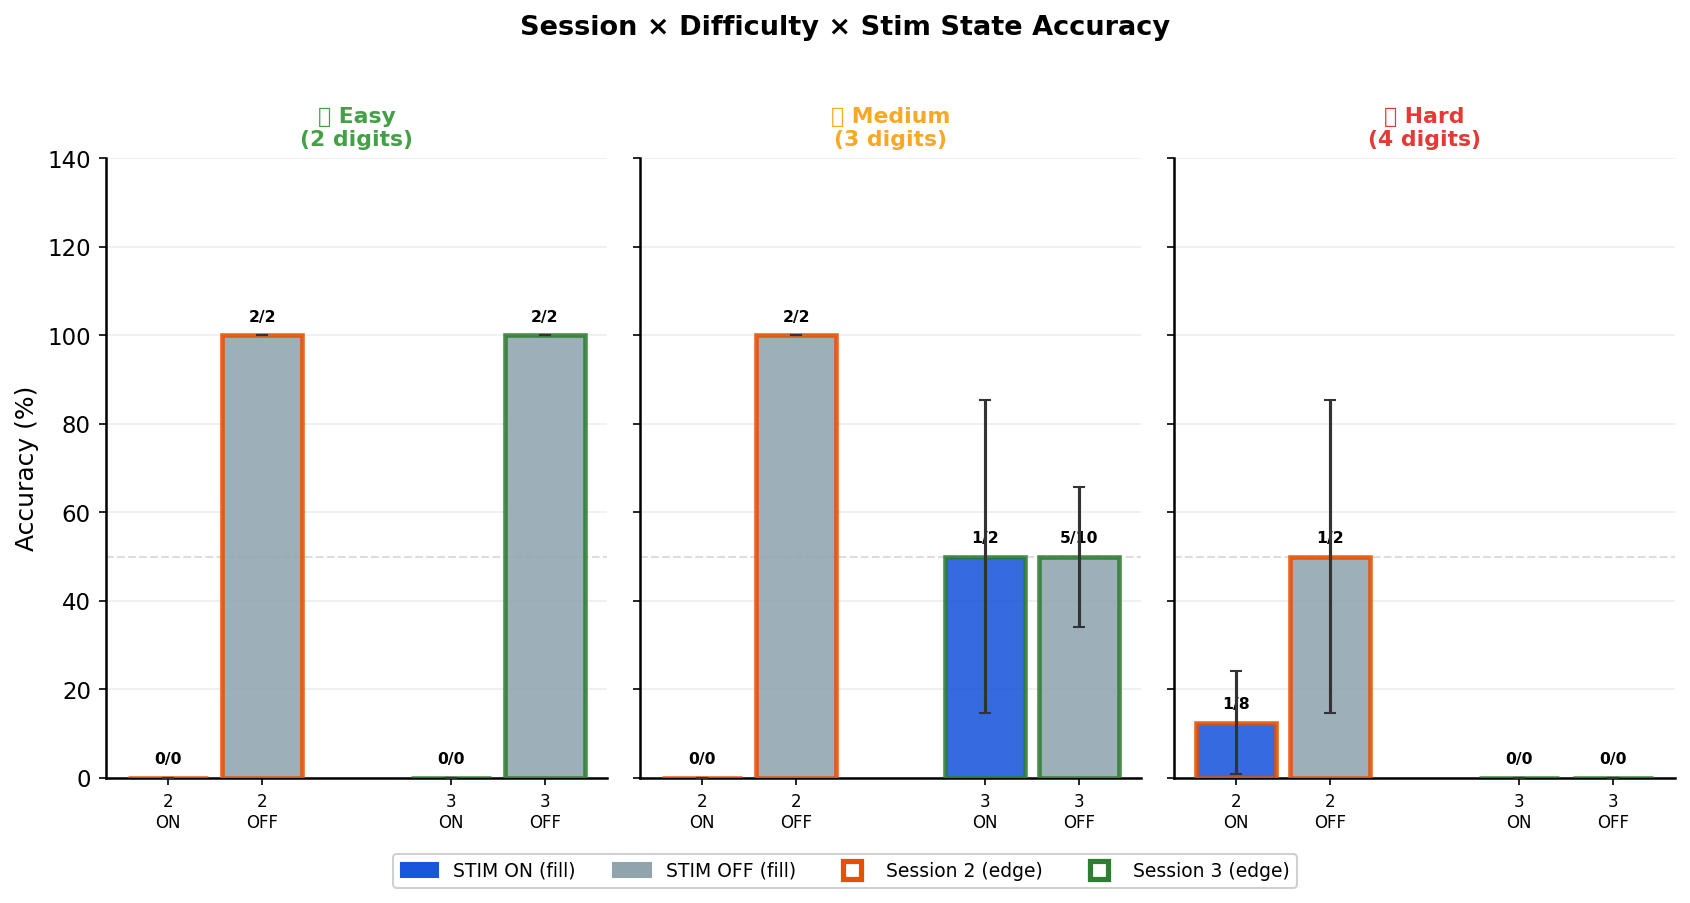

In [14]:
plot_session_x_difficulty(
    df_all,
    save_path=COMBINED_DIR / 'diff_session_x_difficulty.png'
)

## Cell 15 — Final Summary Table

In [15]:
rows = []
for sess_label, df in [('Session 2', df_s2), ('Session 3', df_s3), ('Combined', df_all)]:
    for d in diff_order:
        dm  = DIFF_META.get(d, {})
        sub = df[df['digits']==d]
        on  = sub[sub['stim_on']==True]
        off = sub[sub['stim_on']==False]
        p, rd = fisher_test(int(on['acc'].sum()), len(on),
                             int(off['acc'].sum()), len(off))
        rows.append(dict(
            Session      = sess_label,
            Difficulty   = f"{dm.get('emoji','')} {dm.get('label',str(d))}",
            Digits       = d,
            N_ON         = len(on),
            Acc_ON       = f"{on['acc'].mean()*100:.0f}%" if len(on) else '—',
            N_OFF        = len(off),
            Acc_OFF      = f"{off['acc'].mean()*100:.0f}%" if len(off) else '—',
            p_Fisher     = f'{p:.4f}' if not np.isnan(p) else 'N/A',
            Risk_Diff    = f'{rd:.3f}' if not np.isnan(rd) else 'N/A',
            Significant  = ('✓ YES' if p < 0.05 else 'No') if not np.isnan(p) else 'N/A',
        ))

summary_df = pd.DataFrame(rows)
display(summary_df)

,Session,Difficulty,Digits,N_ON,Acc_ON,N_OFF,Acc_OFF,p_Fisher,Risk_Diff,Significant
0,Session 2,🟢 Easy,2,0,—,2,100%,N/A,N/A,N/A
1,Session 2,🟡 Medium,3,0,—,2,100%,N/A,N/A,N/A
2,Session 2,🔴 Hard,4,8,12%,2,50%,0.3778,-0.375,No
3,Session 3,🟢 Easy,2,0,—,2,100%,N/A,N/A,N/A
4,Session 3,🟡 Medium,3,2,50%,10,50%,1.0000,0.000,No
5,Session 3,🔴 Hard,4,0,—,0,—,N/A,N/A,N/A
6,Combined,🟢 Easy,2,0,—,4,100%,N/A,N/A,N/A
7,Combined,🟡 Medium,3,2,50%,12,58%,1.0000,-0.083,No
8,Combined,🔴 Hard,4,8,12%,2,50%,0.3778,-0.375,No
